<span style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">An Exception was encountered at '<a href="#papermill-error-cell">In [19]</a>'.</span>

In [1]:
%load_ext autoreload
%autoreload 3

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/shared_helper_modules'))

# General imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import pickle

warnings.filterwarnings(
    "ignore",
    message="use_inf_as_na option is deprecated",
    category=FutureWarning,
    module="seaborn")

warnings.filterwarnings(
    "ignore",
    message=r"invalid value encountered in log10",
    category=RuntimeWarning,
    module=r".*specparam.*",
)


# NeuroDSP and FOOOF modules
from neurodsp import spectral

from specparam import Bands


# Custom modules

from spk_feat_cluster_analysis import *

from spe1_plotting import *
from spikeparam.patch.fit import Spike

from config import NPX_CHANNELS, CELL_IDS, DICT_PATCH_FS, DICT_CHAN_PRED, DICT_SPK_THRESH, FILTER_SETTINGS, SPE1_DATA_ROOT, SPE1_PICKLE_ROOT


In [3]:
cell_num = 35 #MODIFY THIS WHEN RUNNING DIFFERENT CELLS 

npx_fs = 30000 # sampling rate
lfp_fs = 3500 # sampling rate

patch_fs = DICT_PATCH_FS[cell_num ]
spk_thresh = DICT_SPK_THRESH[cell_num]

npx_channels = NPX_CHANNELS
npx_patch_channel = DICT_CHAN_PRED[cell_num ]



In [4]:
# Parameters
FORCE_CLUSTER = True


### Loading spe-1 data:

I moved the data loading steps to a separate Jupyter Notebook (spe-1_load_data)




## Cell   
### Analyze Gamma LFP and whole patch clamp AP relationship for cell 

## Step 0: Get loaded data 

In [5]:
lfp_dir = os.path.join(SPE1_DATA_ROOT, 'filt_lfp_recordings', f'c{cell_num}_lfp.npy')
patch_dir = os.path.join(SPE1_DATA_ROOT, 'filt_patch_recordings', f'c{cell_num}_patch.npy')


In [6]:
#get LFP data
lfp_filt = np.load(lfp_dir)
lfp_one_ms = float(lfp_fs / 1000)
lfp_times = np.arange(0, np.shape(lfp_filt)[0]) / lfp_one_ms # in ms instead of sec

#get patch data 
patch_filt = np.load(patch_dir)
patch_one_ms = float(patch_fs  / 1000)
patch_times = np.arange(0, np.shape(patch_filt )[0]) / patch_one_ms # in ms instead of sec

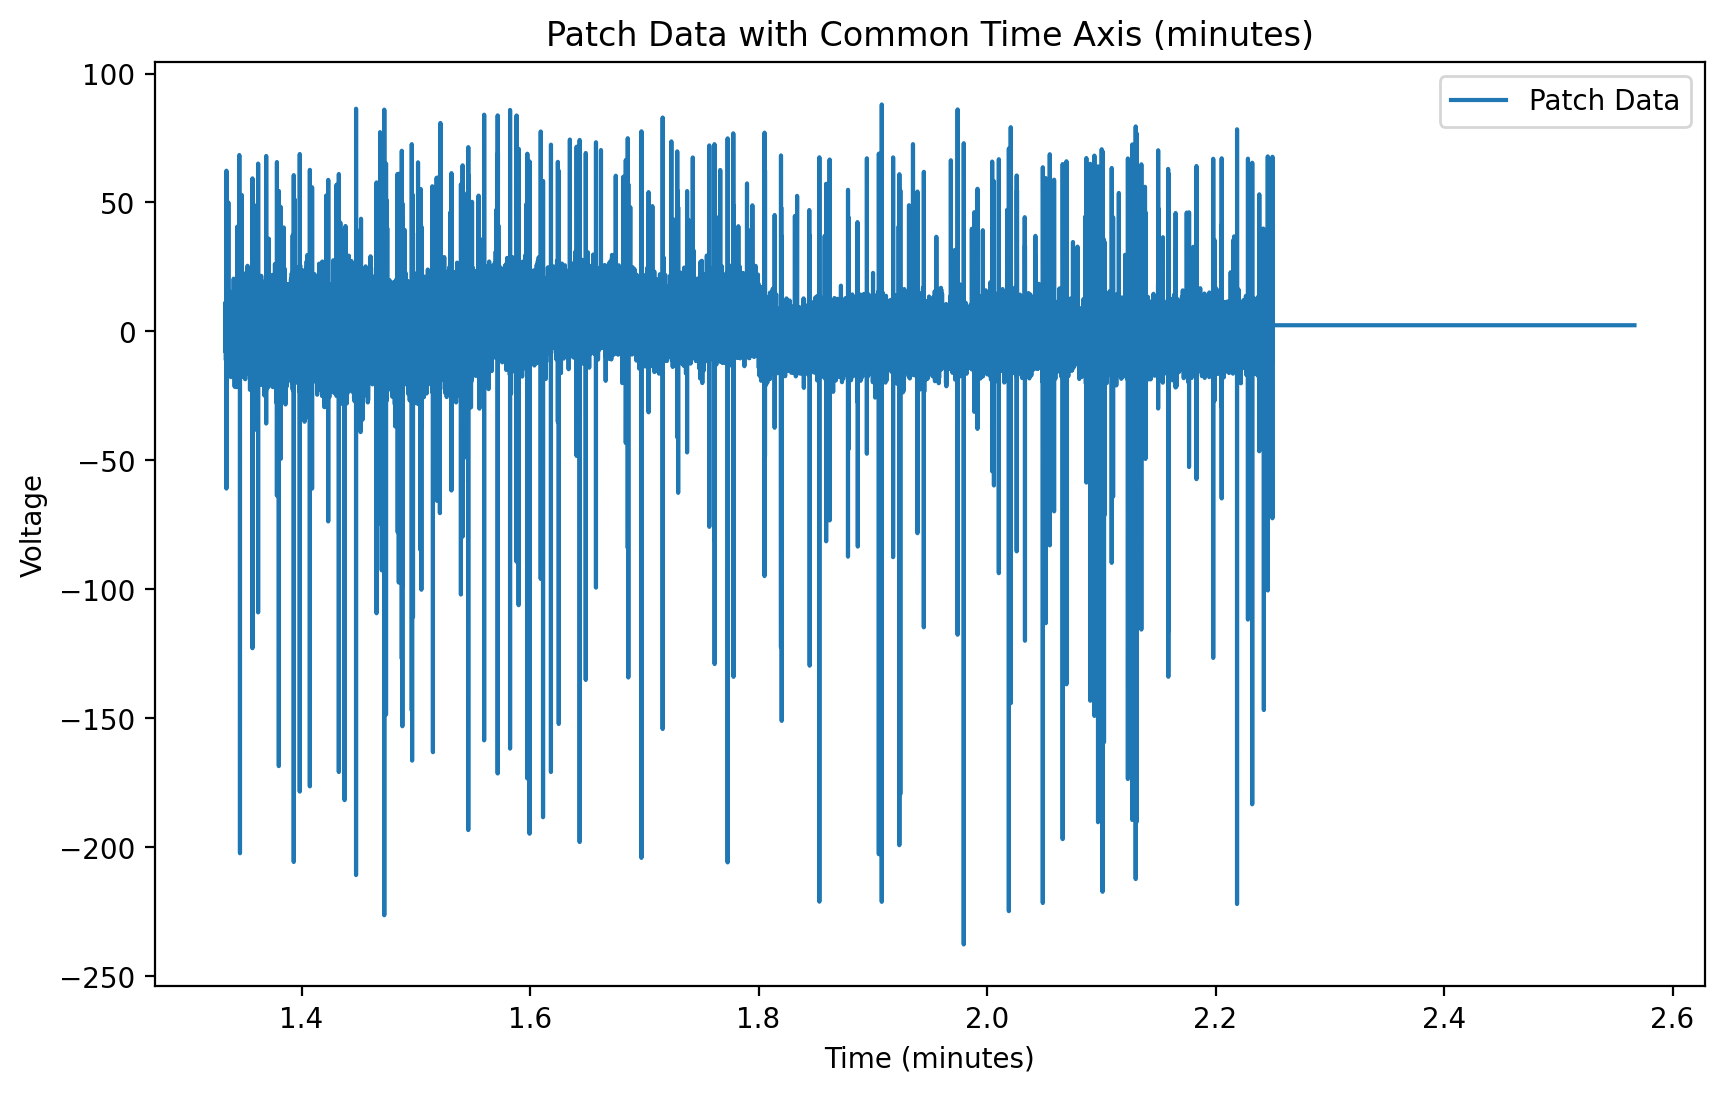

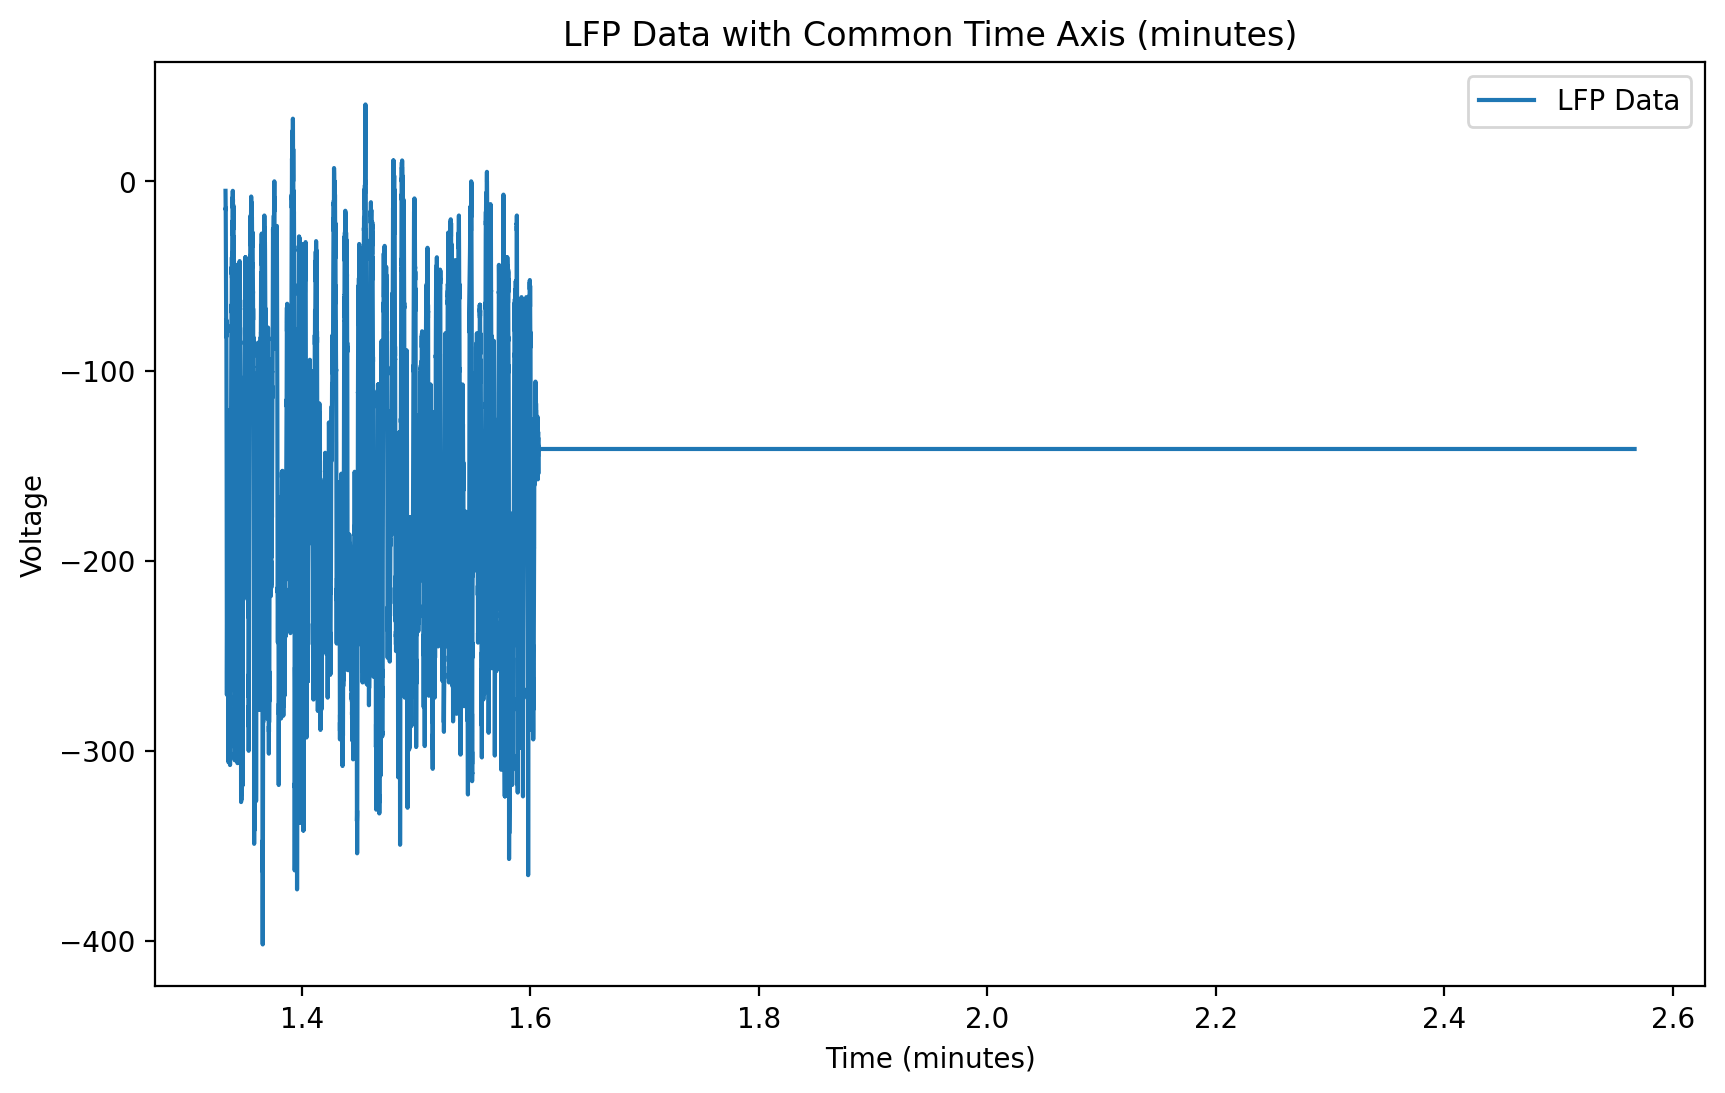

In [7]:
# Plot simultaneous patch and LFP data
# Convert time arrays to minutes
patch_times_min = patch_times / 60000  # Convert milliseconds to minutes
lfp_times_min = lfp_times / 60000  # Convert milliseconds to minutes

# Set the common time axis in minutes (e.g., from 13.3333 to 35.6667 minutes)
common_time_range_min = np.arange(80000 / 60000, 154000 / 60000, 1 / 60000)  # Adjust as needed

# Interpolate patch data onto the common time axis
patch_interp = np.interp(common_time_range_min, patch_times_min, patch_filt)

# Interpolate LFP data onto the common time axis
lfp_interp = np.interp(common_time_range_min, lfp_times_min, lfp_filt)

# Plot patch data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, patch_interp, label='Patch Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('Patch Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

# Plot LFP data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, lfp_interp, label='LFP Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('LFP Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

## STEP 1: Detect and fit spikes from patch data

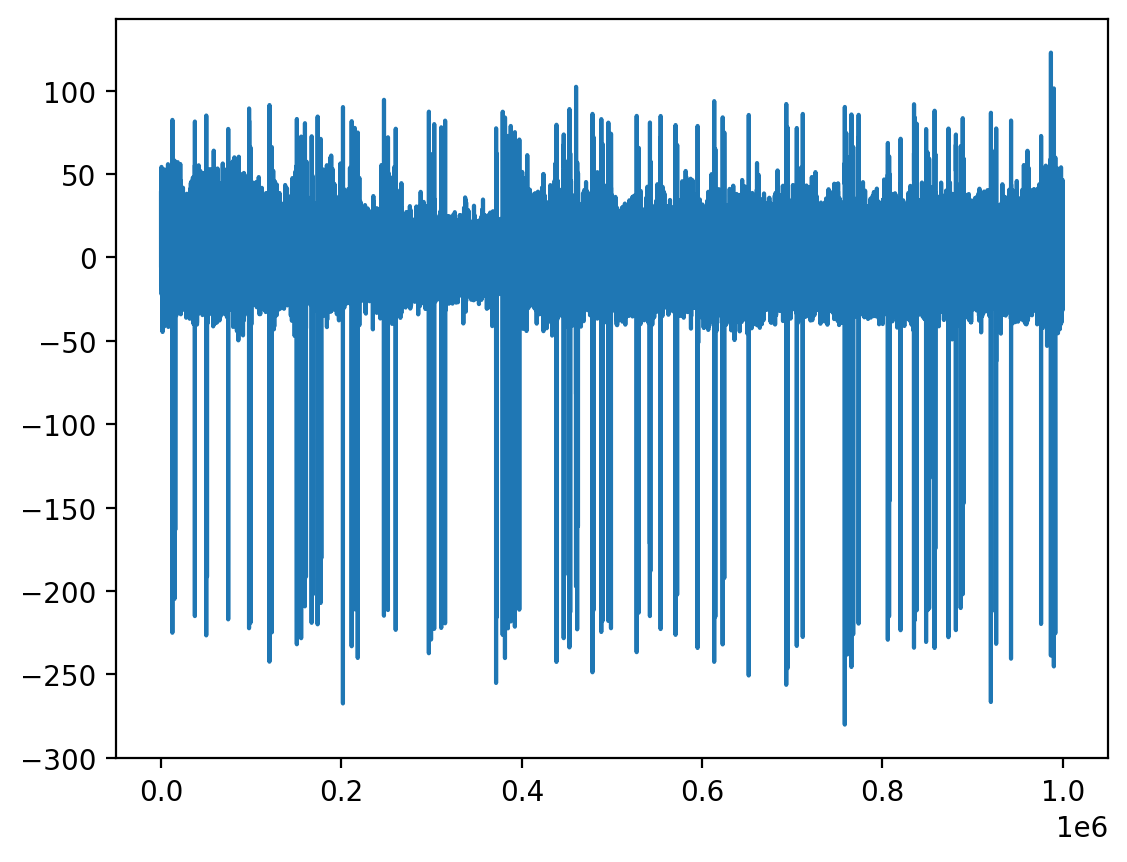

In [8]:
plt.plot(patch_filt[:1000000] )

In [9]:



#threshold in mVs
sp = Spike(thresh_amp=spk_thresh, window_length=(5., 5.), smooth_frac=.01)

In [10]:
#CHANGE FOR EACH CELL
sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm, flip_signal=True)

Spike:   0%|          | 0/680 [00:00<?, ?it/s]

Spike:   0%|          | 1/680 [00:03<37:46,  3.34s/it]

Spike:   1%|          | 5/680 [00:03<05:53,  1.91it/s]

Spike:   7%|▋         | 47/680 [00:03<00:25, 24.84it/s]

Spike:  10%|█         | 68/680 [00:03<00:16, 38.22it/s]

...

Spike:  93%|█████████▎| 632/680 [00:06<00:00, 225.43it/s]

Spike:  96%|█████████▋| 655/680 [00:06<00:00, 225.13it/s]

Spike: 100%|█████████▉| 678/680 [00:06<00:00, 223.87it/s]

Spike: 100%|██████████| 680/680 [00:06<00:00, 105.92it/s]


/Users/blancamartin/opt/anaconda3/envs/spikeparam/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/blancamartin/opt/anaconda3/envs/spikeparam/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


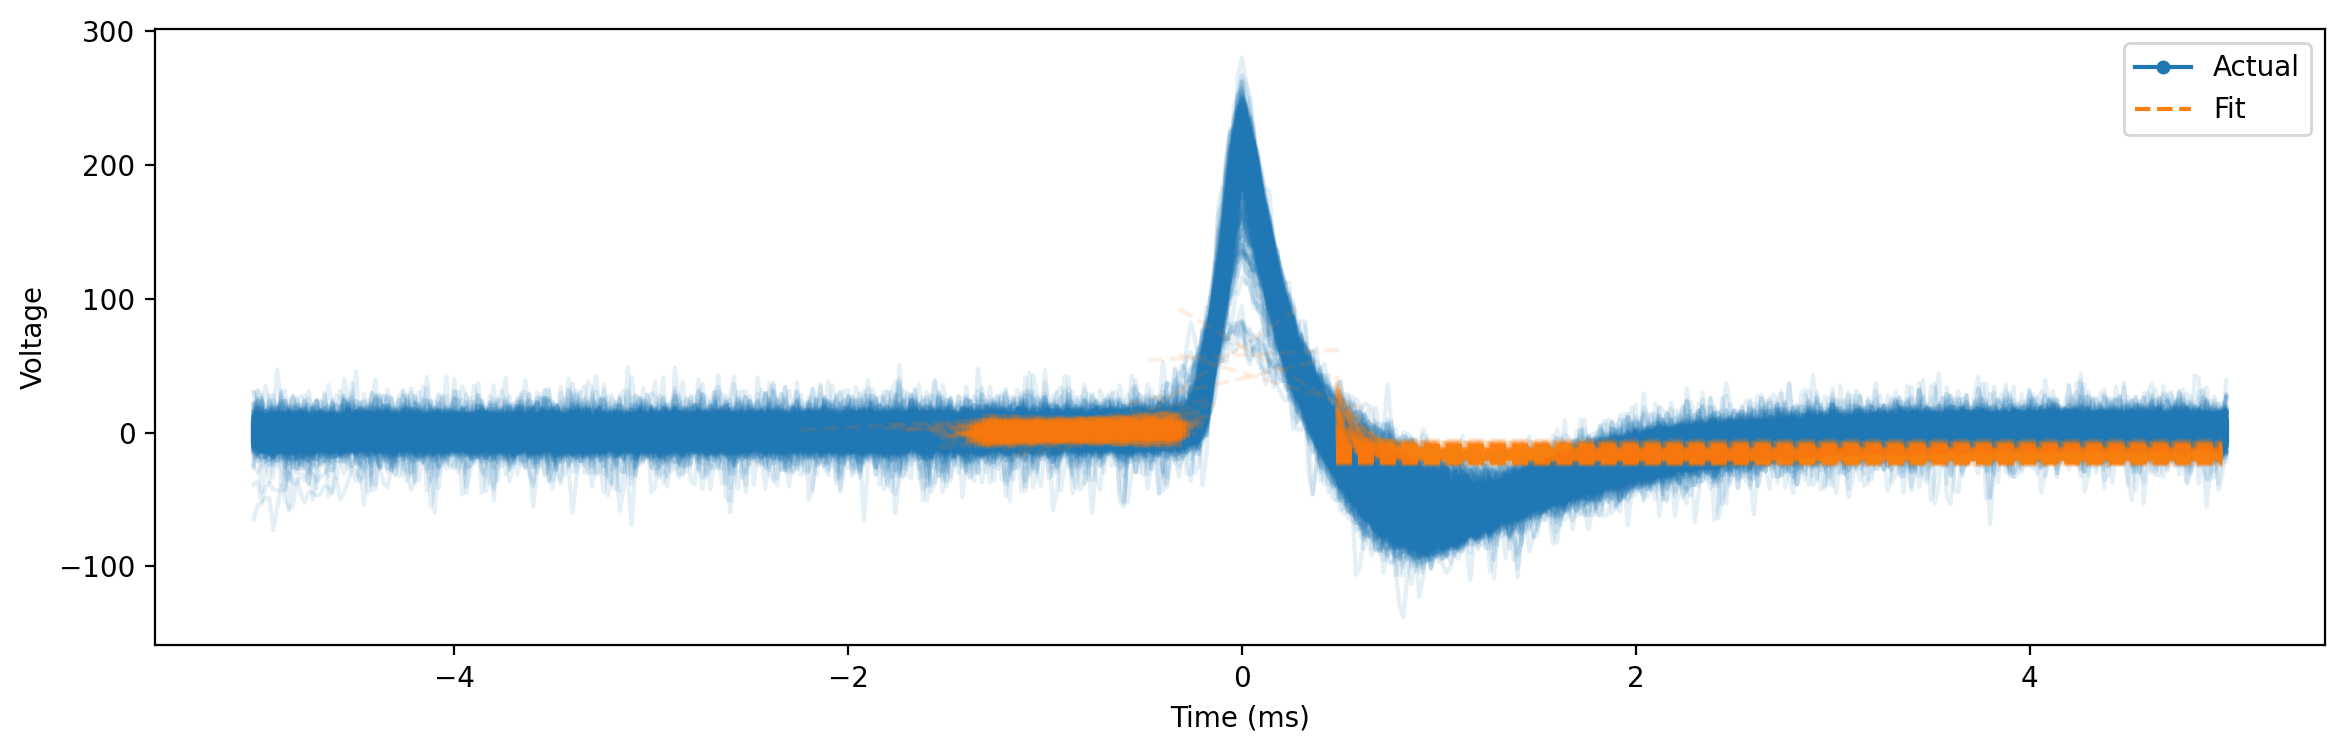

In [11]:
sp.plot()

### Filter spikes 

In [12]:
sp.filter_features()  # Applies default filters in-place

### Get spike dataframe (with spike times column)

In [13]:

df_features = sp.df_features

#add columns for spike times, both in idx and ms
df_features['spk_times_idx'] = sp.spike_inds
df_features['spk_times_ms'] = patch_times[sp.spike_inds]
df_features['spk_id'] = range(len(df_features))

In [14]:
df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,spk_times_ms,spk_id
1,1.722403,0.26,8.424083,200.683187,0.26,77.012631,10.000000,-11.021840,1.245305,14896,297.777734,0
2,3.980370,0.32,8.346385,157.867423,0.28,48.505103,10.000000,-7.314075,2.637962,15776,315.369330,1
3,-3.594314,0.30,-5.921791,201.594086,0.26,84.437620,10.000000,-15.876044,2.401434,37510,749.841757,2
4,4.685157,0.28,3.300944,220.645056,0.26,91.909886,10.000000,-20.250803,1.234816,50117,1001.861353,3
5,3.093142,0.30,4.737085,180.518175,0.30,65.681539,10.000000,-10.587014,2.671964,50976,1019.033149,4
...,...,...,...,...,...,...,...,...,...,...,...,...
675,3.156684,0.32,-5.957502,185.296978,0.28,71.928052,10.000000,-19.565207,2.330206,6717943,134294.699686,660
676,-1.556465,0.24,-1.144038,187.340280,0.32,53.899185,3.972428,-13.338108,1.454942,6728643,134508.597495,661
677,2.931654,0.26,2.672158,186.389436,0.32,54.296356,10.000000,-18.365531,2.308997,6730069,134537.103875,662
678,8.035506,0.28,13.334906,213.967982,0.28,83.441839,10.000000,-19.037703,2.389773,6740259,134740.806555,663


In [15]:
spk_times_idx = df_features['spk_times_idx']
spk_times_ms = df_features['spk_times_ms']
spk_ids = df_features['spk_id']

## STEP 2: Cluster spike groups 

Plotting spike features...
Removing outliers using IQR method (multiplier=3)


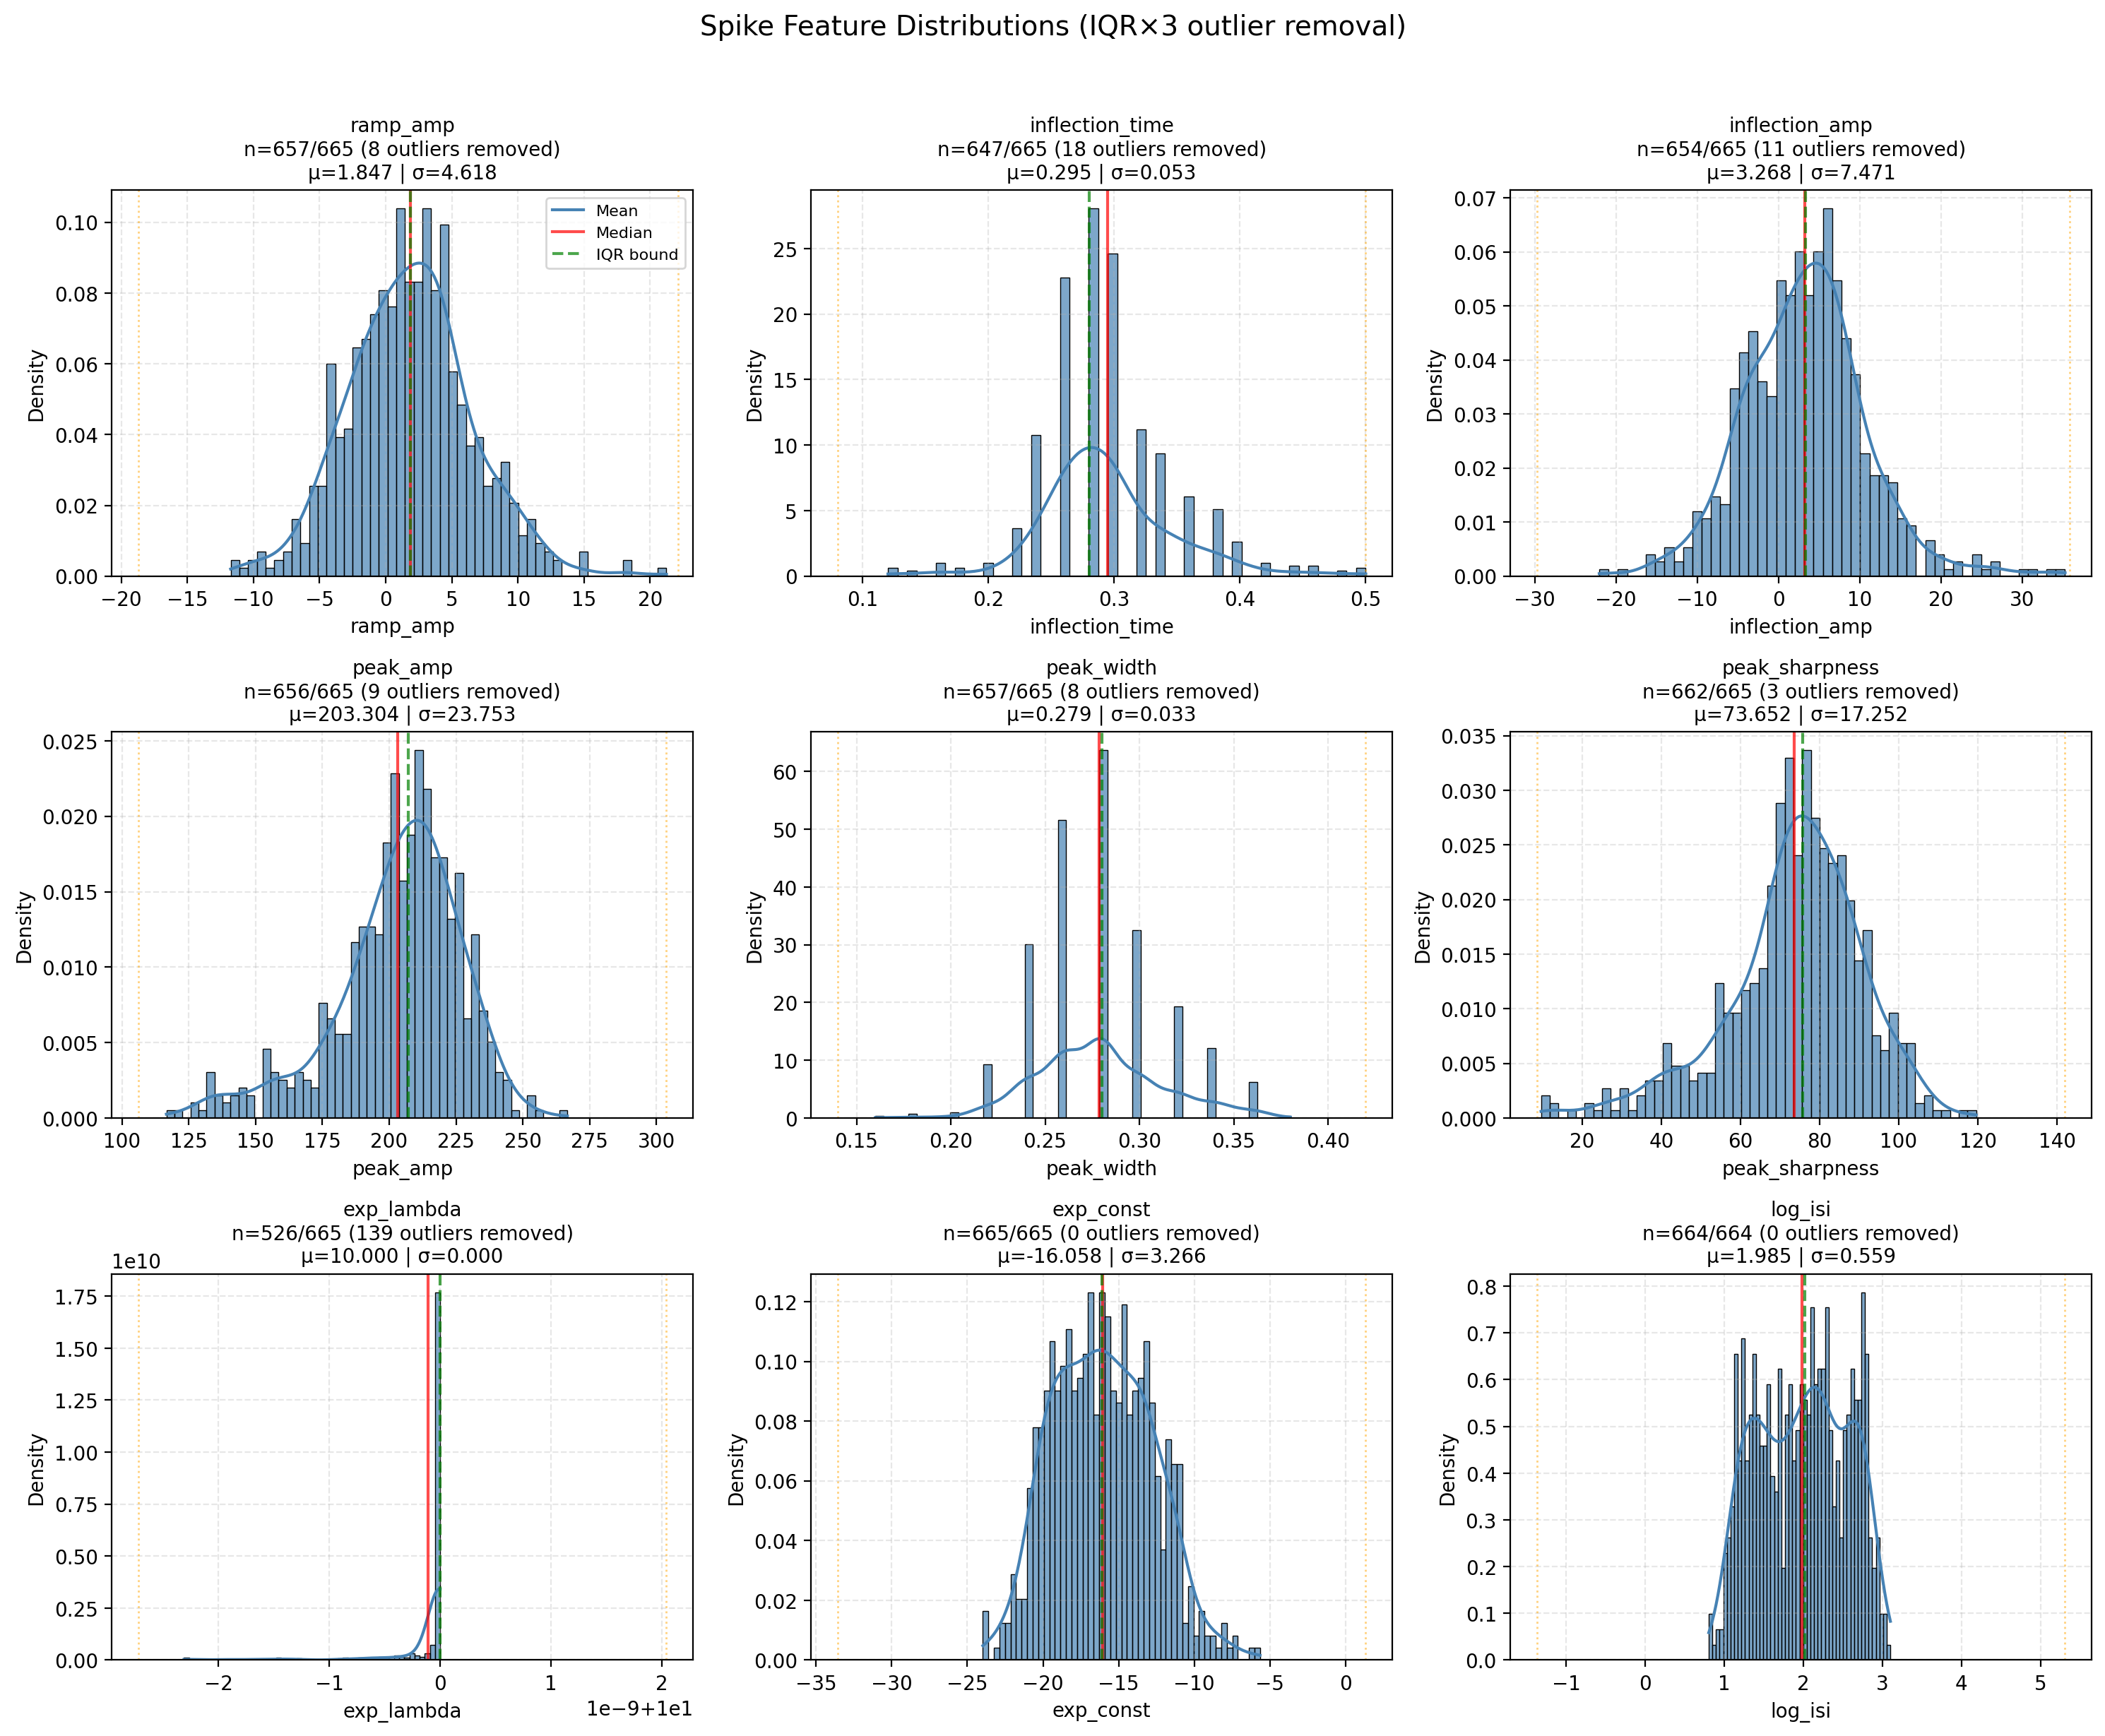


FEATURE DISTRIBUTION SUMMARY
Feature              Total N    Clean N    Outliers   % Removed  Mean       Std       
------------------------------------------------------------------------------------------
ramp_amp             665        657        8          1.2        1.847      4.618     
inflection_time      665        647        18         2.7        0.295      0.053     
inflection_amp       665        654        11         1.7        3.268      7.471     
peak_amp             665        656        9          1.4        203.304    23.753    
peak_width           665        657        8          1.2        0.279      0.033     
peak_sharpness       665        662        3          0.5        73.652     17.252    
exp_lambda           665        526        139        20.9       10.000     0.000     
exp_const            665        665        0          0.0        -16.058    3.266     
log_isi              664        664        0          0.0        1.985      0.559     


In [16]:
plot_spike_feature_distributions(df_features)

ramp_amp: Skipped - k_suggest = 1
→ inflection_time: Skipping (feature ignored).
inflection_amp: Skipped - k_suggest = 1
peak_amp: Skipped - k_suggest = 1
peak_width: Skipped - k_suggest = 1


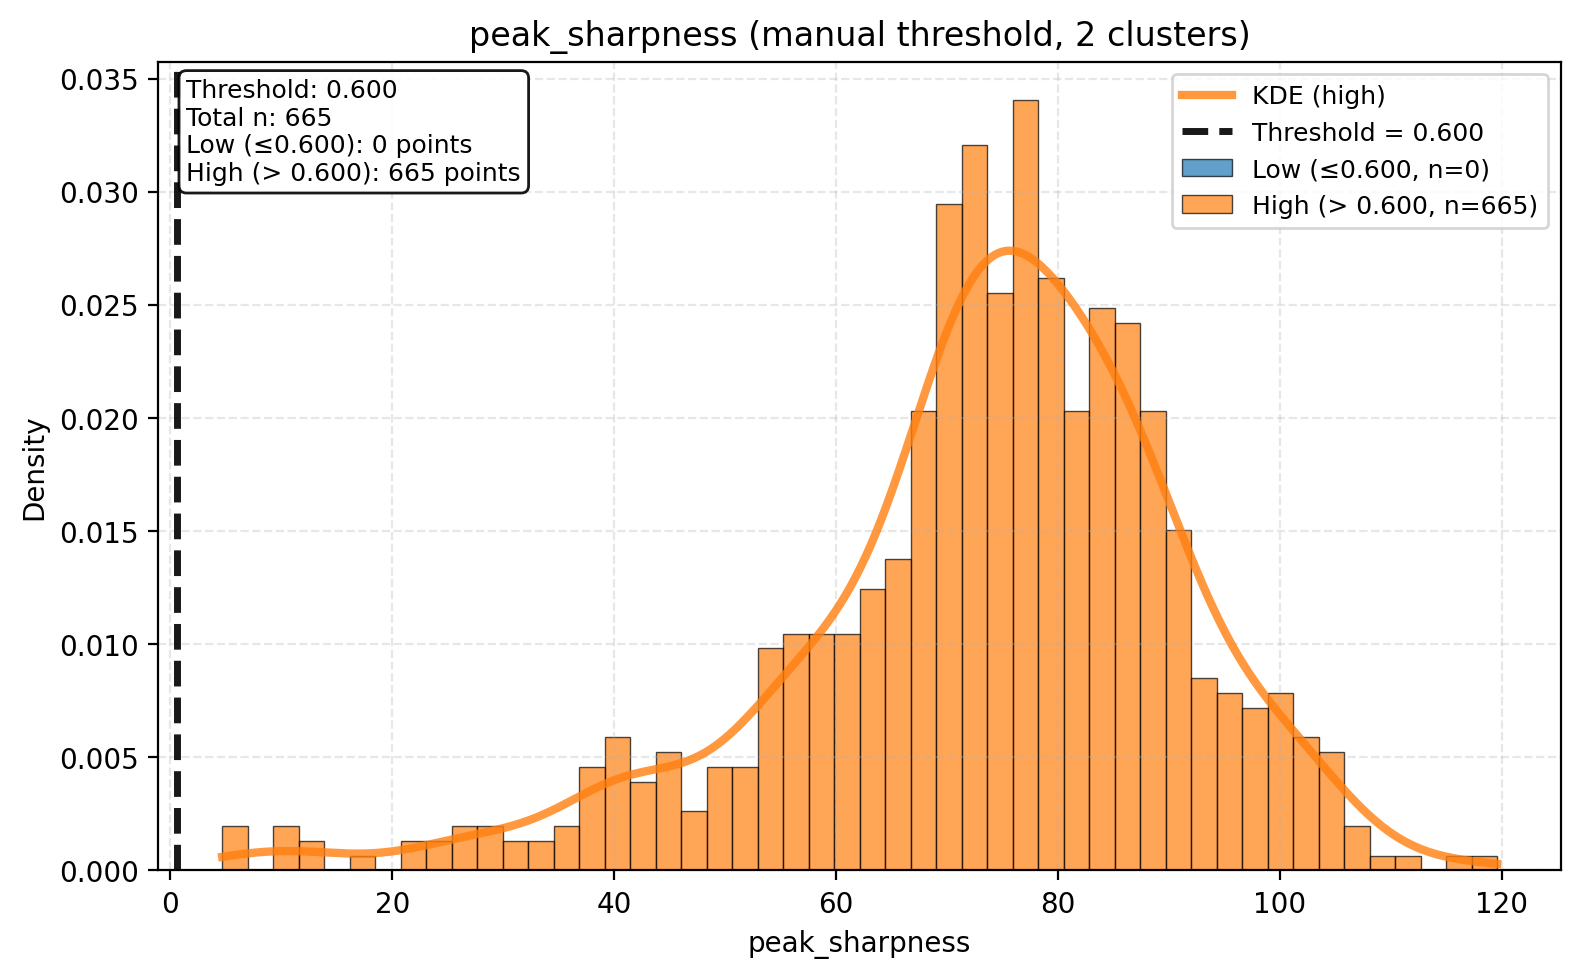

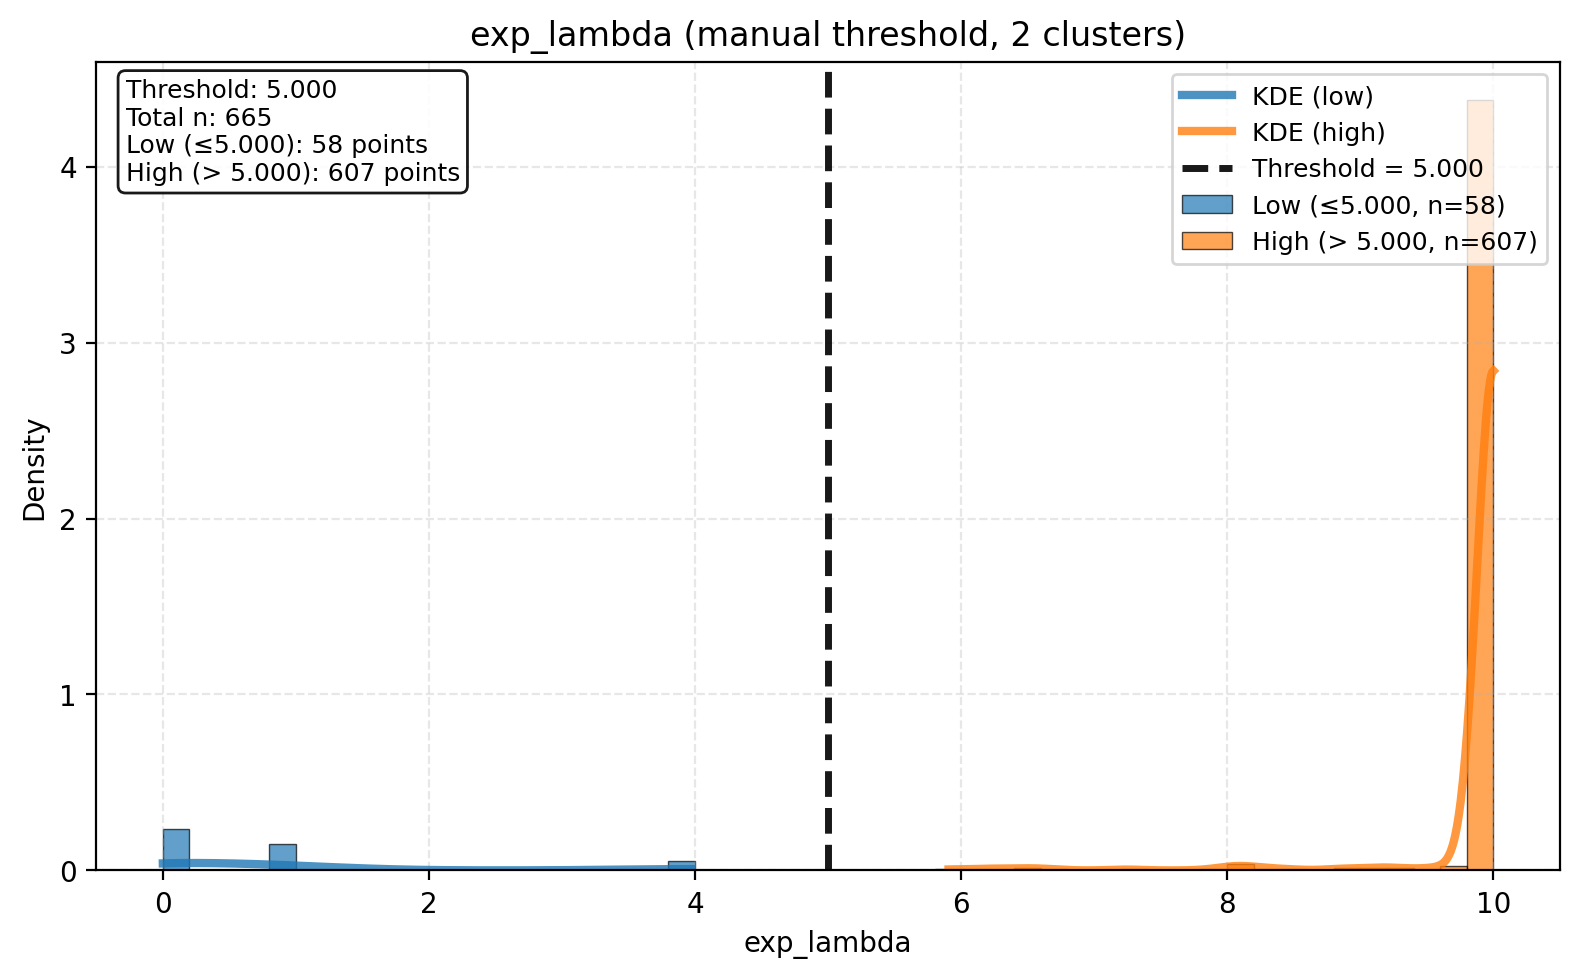

exp_const: Skipped - k_suggest = 1


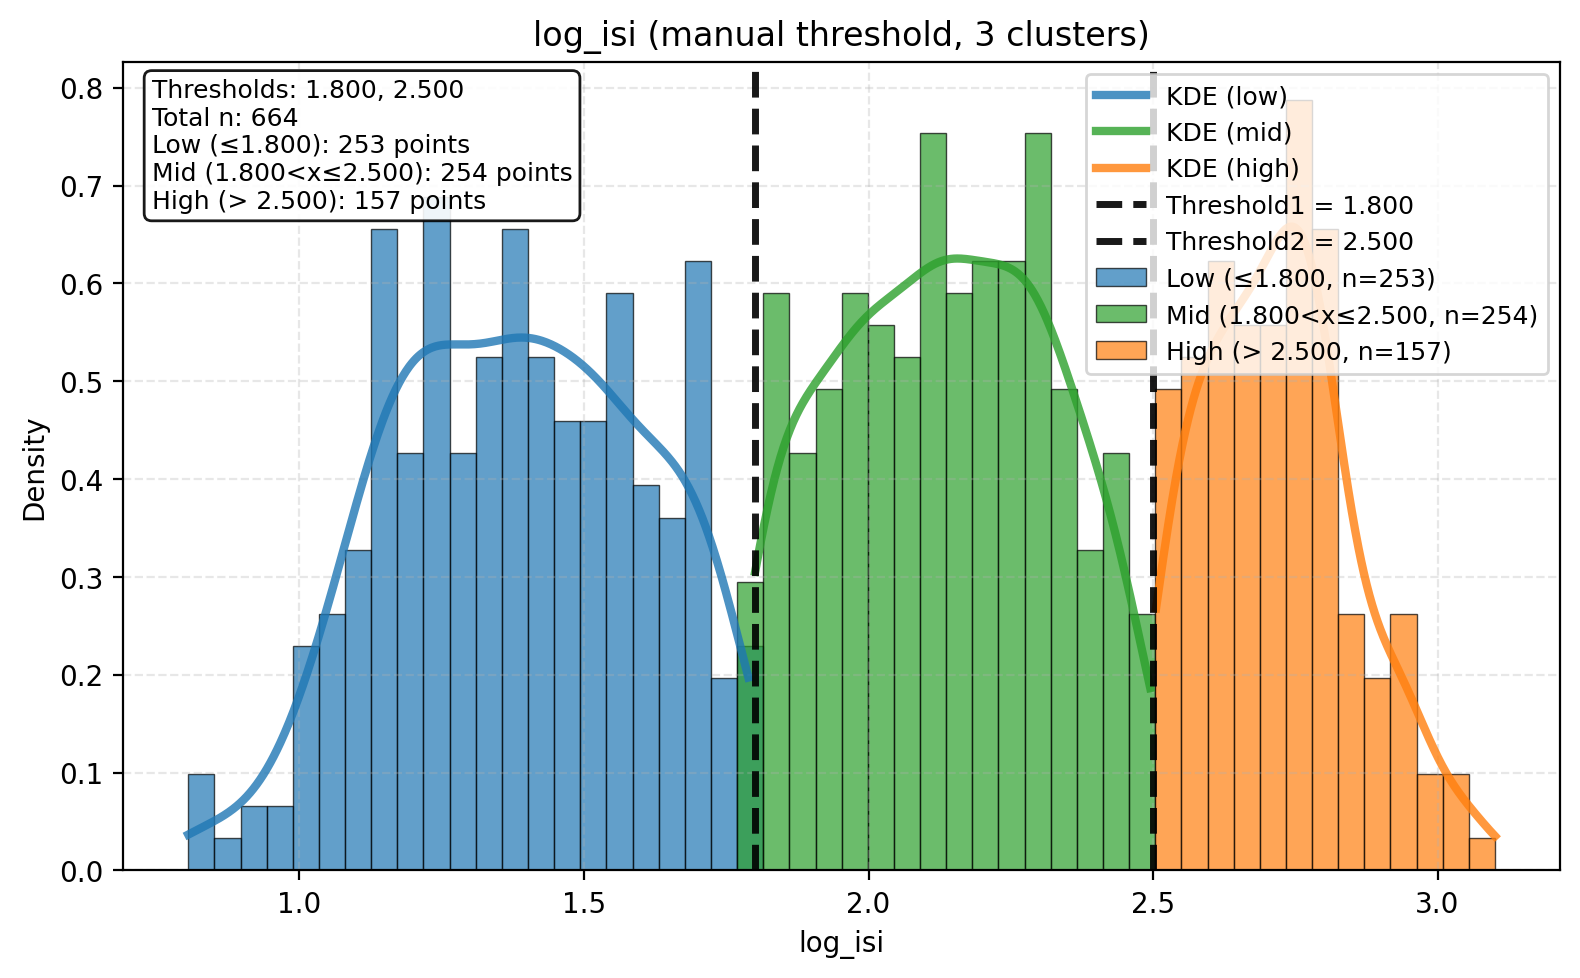

spk_times_ms: Skipped - k_suggest = 1
spk_id: Skipped - k_suggest = 1
  Saved: c35_cluster_df.pkl


In [17]:
cluster_pickle = os.path.join(SPE1_PICKLE_ROOT, 'cluster_pickles', f'c{cell_num}_cluster_df.pkl')

if FORCE_CLUSTER or not os.path.exists(cluster_pickle):
    # scan all numeric features and only cluster the ones that look multimodal
    df_features_clust, rep = cluster_multimodal_features(
        df_features.drop(["spk_times_idx"], axis = 1),
        max_k=3,
        suffix="_cluster",ignore_features = "inflection_time",
        plot_each=True,  # set True if you want a quick plot per clustered feature, 
        manual_thresholds={"peak_sharpness":0.6, "exp_lambda": 5, "log_isi":(1.8, 2.5),
            
        }
    )
    
    
    
    
    
    with open(cluster_pickle, 'wb') as f:
        pickle.dump(df_features_clust, f)
    print(f"  Saved: {os.path.basename(cluster_pickle)}")
else:
    print(f"  [cache] {os.path.basename(cluster_pickle)}")
    with open(cluster_pickle, 'rb') as f:
        df_features_clust = pickle.load(f)


In [18]:
df_features_clust

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_ms,spk_id,peak_sharpness_cluster,exp_lambda_cluster,log_isi_cluster
1,1.722403,0.26,8.424083,200.683187,0.26,77.012631,10.000000,-11.021840,1.245305,297.777734,0,high,high,low
2,3.980370,0.32,8.346385,157.867423,0.28,48.505103,10.000000,-7.314075,2.637962,315.369330,1,high,high,high
3,-3.594314,0.30,-5.921791,201.594086,0.26,84.437620,10.000000,-15.876044,2.401434,749.841757,2,high,high,mid
4,4.685157,0.28,3.300944,220.645056,0.26,91.909886,10.000000,-20.250803,1.234816,1001.861353,3,high,high,low
5,3.093142,0.30,4.737085,180.518175,0.30,65.681539,10.000000,-10.587014,2.671964,1019.033149,4,high,high,high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
675,3.156684,0.32,-5.957502,185.296978,0.28,71.928052,10.000000,-19.565207,2.330206,134294.699686,660,high,high,mid
676,-1.556465,0.24,-1.144038,187.340280,0.32,53.899185,3.972428,-13.338108,1.454942,134508.597495,661,high,low,low
677,2.931654,0.26,2.672158,186.389436,0.32,54.296356,10.000000,-18.365531,2.308997,134537.103875,662,high,high,mid
678,8.035506,0.28,13.334906,213.967982,0.28,83.441839,10.000000,-19.037703,2.389773,134740.806555,663,high,high,mid


### CLUSTER REPORTS

<span id="papermill-error-cell" style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">Execution using papermill encountered an exception here and stopped:</span>


===== CLUSTER REPORT: peak_sharpness_cluster =====
Found 1 clusters: ['high']

→ Determining cluster colors and labels...
  Using existing cluster labels: ['high']
  Groups: ('high',)
  Group names: ('High',)

→ 1. Plotting spike waveforms by cluster


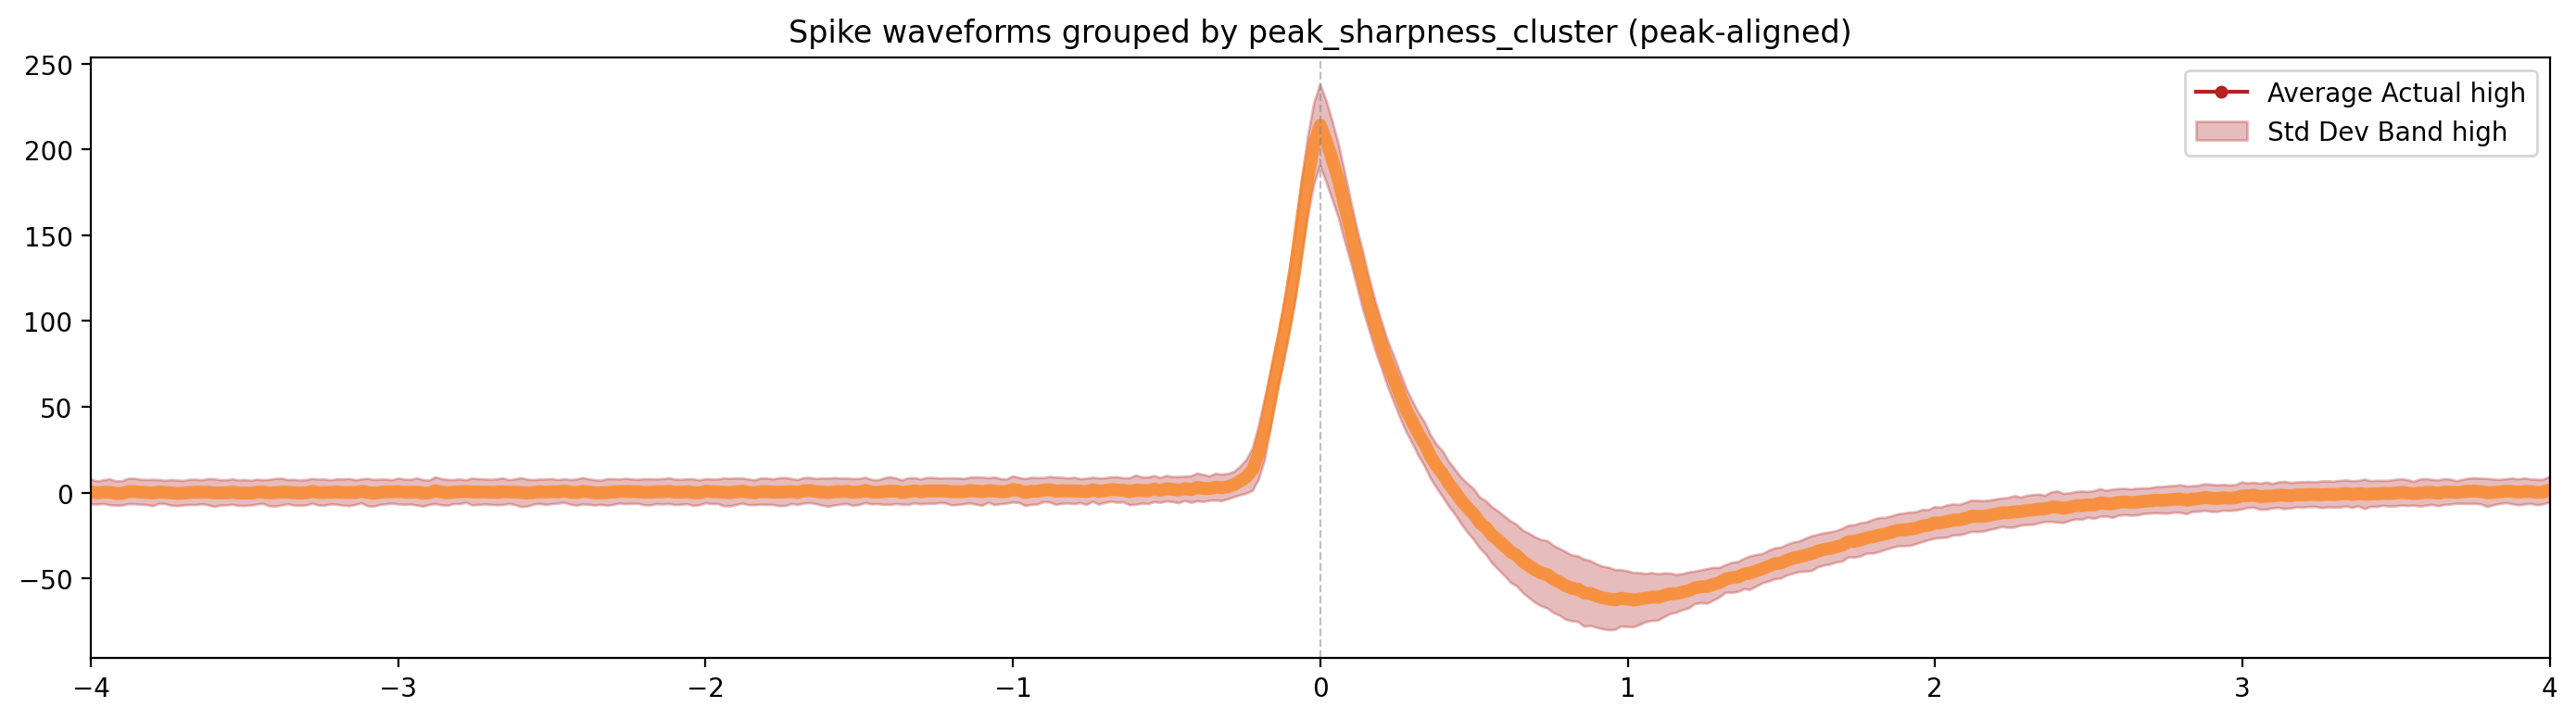


→ 1.5 Average waveforms with visual RMSE

→ 2. Plotting cluster proportions over time


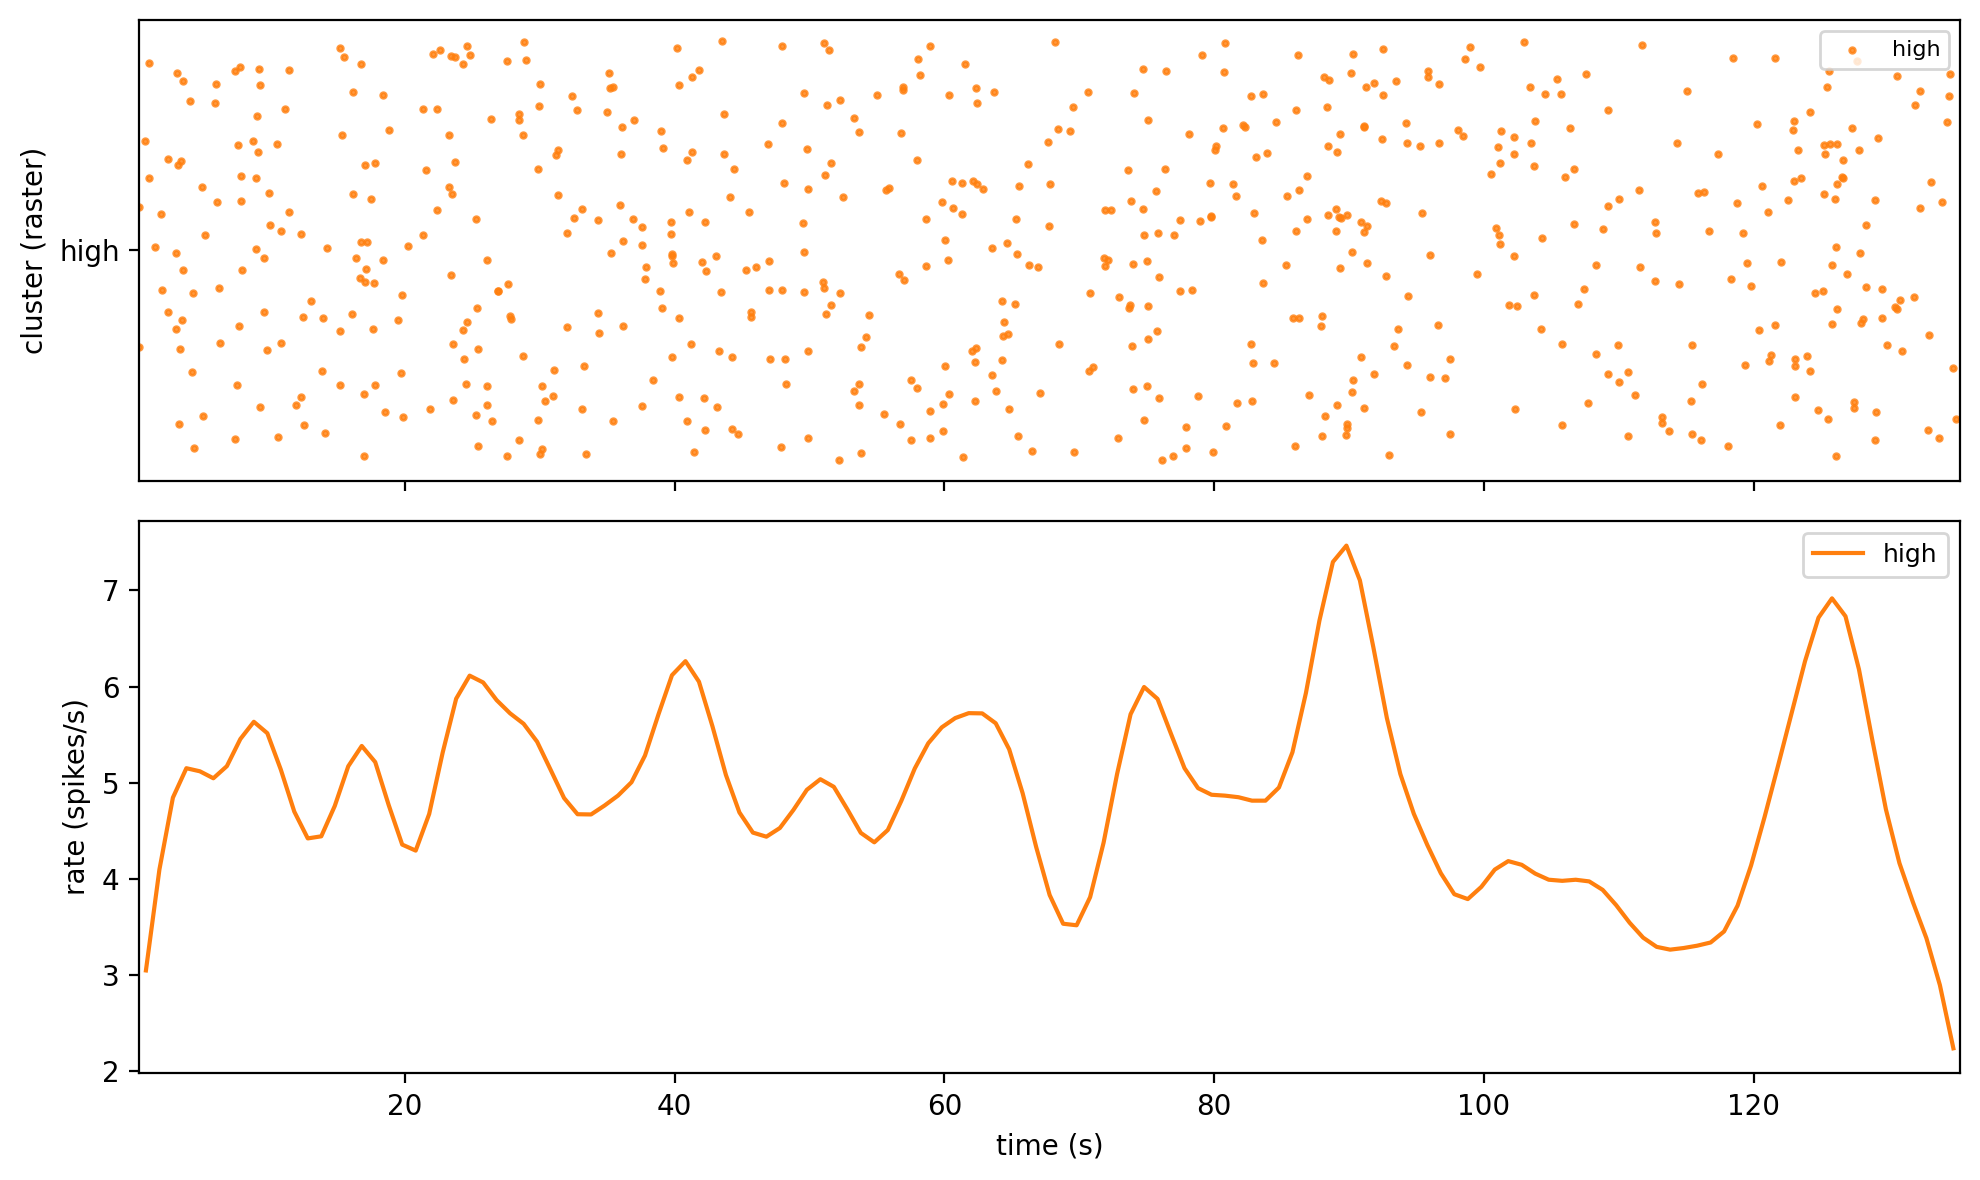


→ 3. Computing cluster transition matrix


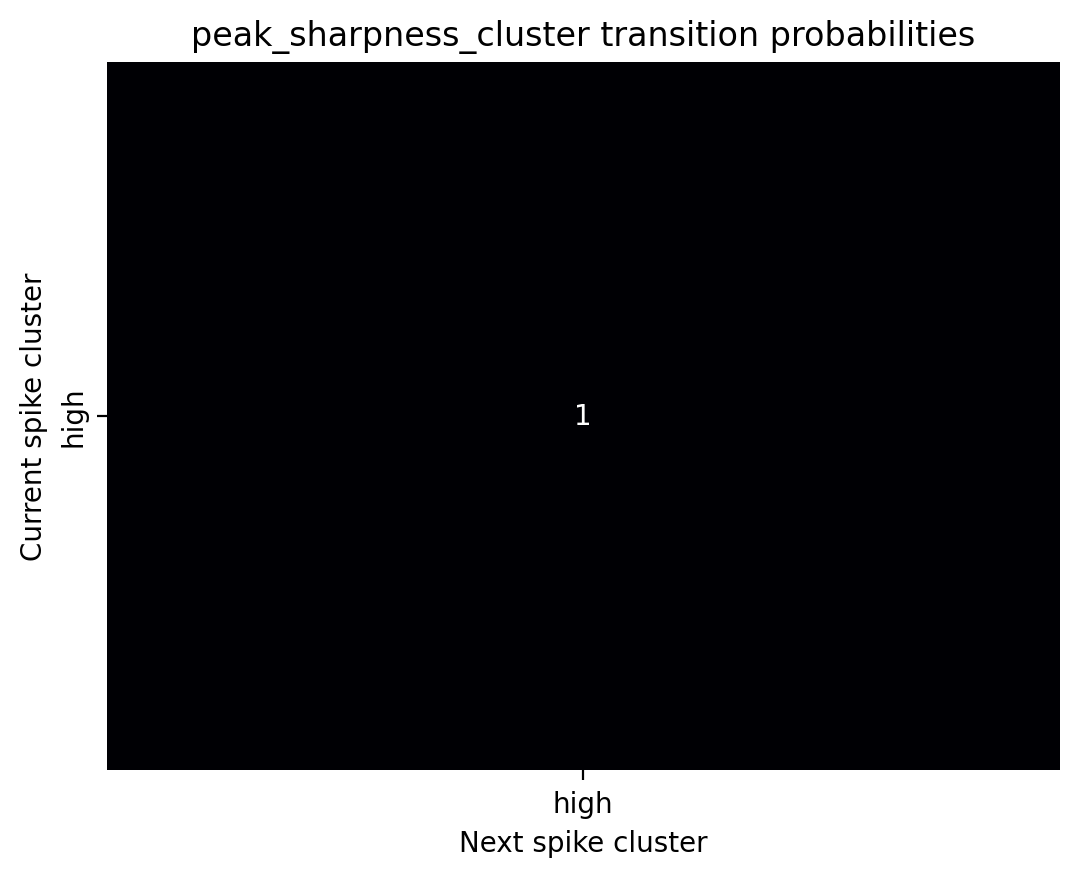


→ 4. Visualizing feature distributions by cluster
  [skip] visualize_feature_groups_hist: only 1 group(s), need ≥2

→ 5. Statistical analysis for: peak_sharpness
----------------------------------------


IndexError: tuple index out of range

In [19]:
all_reports = []

# Filter columns first to ensure the index is continuous
cluster_cols = [c for c in df_features_clust.columns if c.endswith("_cluster")]

for i, col in enumerate(cluster_cols):
    # Pass 'i' as the cluster_group_id
    row_df = plot_full_cluster_report(df_features_clust, sp, col, cluster_group_id=i)
    all_reports.append(row_df)

# Final Master DataFrame
master_report_df = pd.concat(all_reports, ignore_index=True)

In [ ]:
# Save cluster quality report for population-level comparison analysis
report_pickle = os.path.join(SPE1_PICKLE_ROOT, 'cluster_pickles', f'c{cell_num}_cluster_report.pkl')
with open(report_pickle, 'wb') as f:
    pickle.dump(master_report_df, f)


In [ ]:
# Compute and save peak-aligned average waveforms for each cluster group.
# Saved to a lightweight pickle used by the population comparison notebook.
wf_pickle = os.path.join(SPE1_PICKLE_ROOT, 'cluster_pickles', f'c{cell_num}_cluster_waveforms.pkl')
if FORCE_CLUSTER or not os.path.exists(wf_pickle):
    cluster_cols = [c for c in df_features_clust.columns if c.endswith('_cluster')]
    wf_data = compute_cluster_waveforms(sp, df_features_clust, cluster_cols)
    with open(wf_pickle, 'wb') as f:
        pickle.dump(wf_data, f)
    print(f"  Saved: {os.path.basename(wf_pickle)}")
else:
    print(f"  [cache] {os.path.basename(wf_pickle)}")
